# Scalebars in spatialdata-plot

A scalebar tells the reader the physical size of what they are looking at. `spatialdata-plot` draws one through the `scalebar_*` arguments of `.pl.show()`. The one thing to get right is `scalebar_dx`: because SpatialData coordinate systems carry **no physical-unit metadata**, you have to tell the plot how large one axes-unit is.

By the end you should be able to:

- Add a scalebar and explain what `scalebar_dx` means and why it is required.
- Choose the unit with `scalebar_units` and let the bar auto-scale (µm → mm).
- Style the bar (placement, colour, box, length, fonts) via `scalebar_params`.
- Pin an exact bar length with `fixed_value`.

We use the synthetic `blobs` dataset throughout so the notebook stays small and reproducible. Its images have no real-world scale, so we will *pretend* they were acquired at 0.5 µm per pixel.

## Setup

In [1]:
import spatialdata as sd
import spatialdata_plot  # noqa: F401  # registers the .pl accessor

sdata = sd.datasets.blobs()
sdata

SpatialData object
├── Images
│     ├── 'blobs_image': DataArray[cyx] (3, 512, 512)
│     └── 'blobs_multiscale_image': DataTree[cyx] (3, 512, 512), (3, 256, 256), (3, 128, 128)
├── Labels
│     ├── 'blobs_labels': DataArray[yx] (512, 512)
│     └── 'blobs_multiscale_labels': DataTree[yx] (512, 512), (256, 256), (128, 128)
├── Points
│     └── 'blobs_points': DataFrame with shape: (<Delayed>, 4) (2D points)
├── Shapes
│     ├── 'blobs_circles': GeoDataFrame shape: (5, 2) (2D shapes)
│     ├── 'blobs_multipolygons': GeoDataFrame shape: (2, 1) (2D shapes)
│     └── 'blobs_polygons': GeoDataFrame shape: (5, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (26, 3)
with coordinate systems:
    ▸ 'global', with elements:
        blobs_image (Images), blobs_multiscale_image (Images), blobs_labels (Labels), blobs_multiscale_labels (Labels), blobs_points (Points), blobs_circles (Shapes), blobs_multipolygons (Shapes), blobs_polygons (Shapes)

## 1. The one required piece: `scalebar_dx`

`scalebar_dx` is the physical size of **one axes-unit**. The `blobs` image is indexed in pixels, so one axes-unit is one pixel; at our assumed resolution that is 0.5 µm. Pass that as `scalebar_dx`, and the unit it is measured in as `scalebar_units`. Note that `scalebar_dx` should be a float.

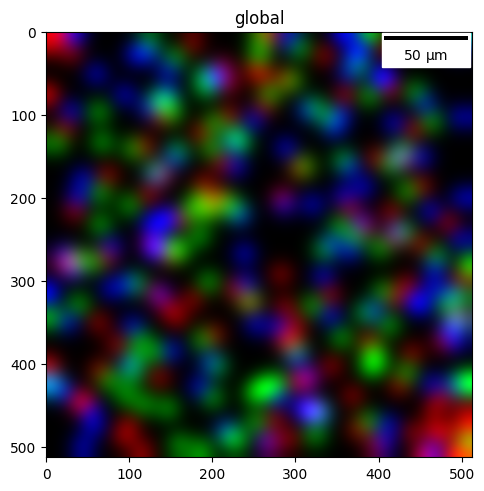

In [2]:
PX_SIZE_UM = 0.5  # physical size of one pixel, taken from the acquisition metadata

sdata.pl.render_images("blobs_image").pl.show(
    scalebar_dx=PX_SIZE_UM,
    scalebar_units="um",
)

Without `scalebar_dx` there is **no scalebar** — the plot has no way to know the physical size, and it never guesses. Two things worth remembering:

- If your coordinate system is in **pixels**, `scalebar_dx` is the micron-per-pixel value.
- If a transformation already put the coordinate system in **physical units** (µm), then one axes-unit is one µm, so `scalebar_dx=1.0`.

In multi-panel plots the same scalebar is drawn on every panel.

## 2. Units and auto-scaling

`scalebar_units` is simply the unit your `scalebar_dx` is expressed in. matplotlib-scalebar then picks a human-friendly magnitude automatically: a bar spanning thousands of µm is shown in mm. The same image at a coarse 50 µm/pixel gives a bar labelled in mm:

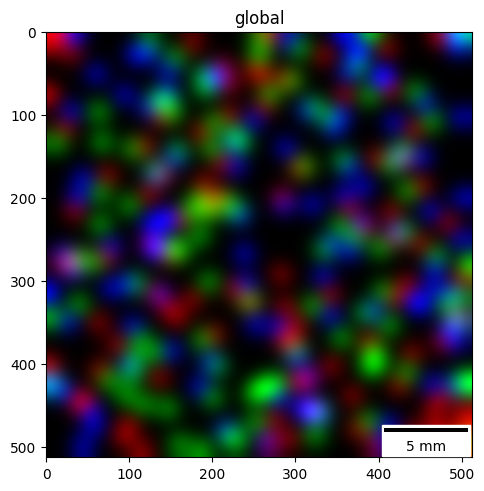

In [3]:
sdata.pl.render_images("blobs_image").pl.show(
    scalebar_dx=50.0,  # coarse resolution: 50 µm per pixel
    scalebar_units="um",
    scalebar_params={"location": "lower right"},
)

## 3. Placement and appearance with `scalebar_params`

`scalebar_params` is a dict forwarded **verbatim** to matplotlib-scalebar's `ScaleBar`, so every option it supports is available. The ones you will reach for most:

- `location` — which corner (`"lower right"`, `"upper left"`, …).
- `color` — bar and text colour (use white on dark images).
- `frameon` / `box_alpha` / `box_color` — the background box behind the bar.
- `length_fraction` — target bar length as a fraction of the axes width.
- `scale_loc` / `label_loc` — where the number and unit sit relative to the bar.

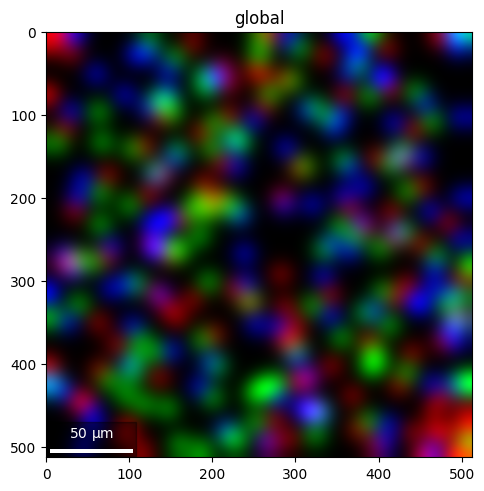

In [4]:
sdata.pl.render_images("blobs_image").pl.show(
    scalebar_dx=PX_SIZE_UM,
    scalebar_units="um",
    scalebar_params={
        "location": "lower left",
        "color": "white",
        "box_color": "black",
        "box_alpha": 0.4,
        "length_fraction": 0.25,
        "scale_loc": "top",
    },
)

Font styling goes through `font_properties`, a matplotlib font dict:

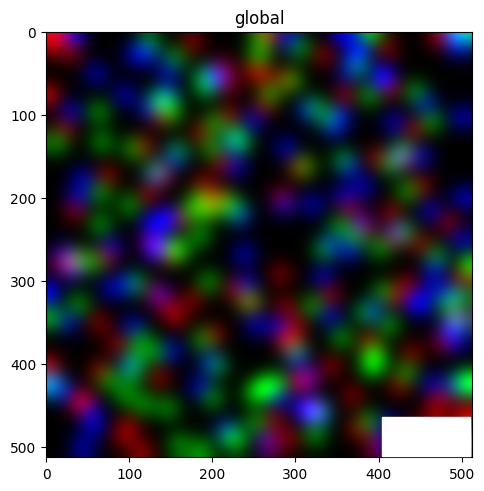

In [5]:
sdata.pl.render_images("blobs_image").pl.show(
    scalebar_dx=PX_SIZE_UM,
    scalebar_units="um",
    scalebar_params={
        "location": "lower right",
        "color": "white",
        "font_properties": {"size": 14, "weight": "bold"},
    },
)

## 4. Pinning an exact bar length

By default the bar snaps to a round length near `length_fraction`. To force an exact length — e.g. a 100 µm bar for a figure panel — set `fixed_value` (and `fixed_units`):

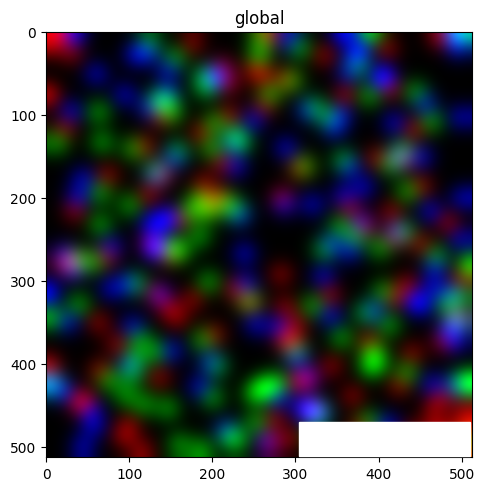

In [6]:
sdata.pl.render_images("blobs_image").pl.show(
    scalebar_dx=PX_SIZE_UM,
    scalebar_units="um",
    scalebar_params={
        "location": "lower right",
        "color": "white",
        "fixed_value": 100,
        "fixed_units": "um",
    },
)

## 5. Everything else, and on real data

Because `scalebar_params` is forwarded to matplotlib-scalebar, anything that library supports (`rotation`, `width_fraction`, custom formatters, …) works too — see the [matplotlib-scalebar documentation](https://github.com/ppinard/matplotlib-scalebar) for the full list.

For a scalebar on a real dataset with a genuine micron-per-pixel value, see the {doc}`Visium mouse brain example </notebooks/examples/visium_mouse_brain>`, which finishes with a publication-style figure.

## For reproducibility

In [ ]:
# ruff: noqa: F401, F811, I001, E402
# fmt: off
import spatialdata_plot

%load_ext watermark
# fmt: on
%watermark -v -m -p spatialdata,spatialdata_plot,matplotlib,matplotlib_scalebar